# Cost saving opportunity for HCP

This jupyter notebook uses the following HCE table to get CPU utilization and AWS cost dataset:
* uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
* uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view

Please read [this decision record](https://salesforce.quip.com/9u7CATaZNDz8) to understand how to calculate the utilization and cost.


If P95 CPU Utilization < 35%:

$$
  Saving Opportunity = \left(HCE Pod Cost ($) * 0.5\right) \times \left( 1-\frac{P95 CPU Utilization}{35} \right)
$$



## Initialization

In [96]:
%reload_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../'))
sys.path.insert(0, module_path)

from huron.pod import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
from datetime import datetime, timedelta
from collections import Counter

# If you want to print out SQL Query, set log level to logging.INFO.
logging.getLogger().setLevel(logging.INFO)

## Connect to UIP

### Option 1: UIP Notebook (Recommended)

Create Notebook by following [User Guide - UIP Notebook 2.0](https://confluence.internal.salesforce.com/display/UIP/User+Guide+-+UIP+Notebook+2.0#UserGuideUIPNotebook2.0-Prerequisites).

### Option 2: Local environment

1. Download [cacert.pem](https://git.soma.salesforce.com/Infrastructure-Security/puppet_pki_agent/blob/master/files/prod_ca/cacerts.pem) and save it as `.cacert.pem`
2. Copy the trino access code from [Salesforce trino authenticator](https://bdmpresto-access-server.sfproxy.uip.aws-esvc1-useast2.aws.sfdc.cl/)
3. Update the [.secrets.json](./.secrets.json) file

```json
{
    "username": "your_user_name",
    "access_code": "trino_access_code"
}
```

In [97]:
conn = None

try:
    from huron import connect_huron
    conn = connect_huron()
except:
    from uip_client.trino import TrinoConnection

    conn = TrinoConnection(
        catalog='huron-metrics',
        schema='metrics_hourly'
    )

INFO:root:Using Certificate Authentication...


## 2. Configure environment

By default, this script queries the metrics for `stage`, `esvc`, and `prod` environments. If you want to change the environment, please edit `ENV_TYPE` below.

In [98]:
ENV_TYPE = ['dev', 'test', 'perf','prod', 'stage', 'esvc']

TIMERANGE_FROM = '2025-06-01 00:00:00'
TIMERANGE_TO = '2025-06-30 00:00:00'

# Configure maximum rows for displaying dataframes
pd.options.display.max_rows = 100
# Configure maximum cols for displaying dataframes
pd.options.display.max_columns = 50
pd.options.display.float_format = '{:.3f}'.format

NAMESPACES = ["sam-system", "kube-system"]

# Set default custom filter. filter only sam cluster.
CUSTOM_FILTERS = "k8s_cluster like 'sam-%'"
# e.g. filter out coredns pod
#CUSTOM_FILTERS = "k8s_cluster like 'sam-%' AND k8s_pod_name like 'coredns%'"

In [99]:
# The following template gets the maximum request cpu and memory from kube-stat-metric
SQL_RESOURCE_TEMPLATE = """
with dedupe as (
  SELECT
      _time,
      scope,
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
      k8s_container_name,
      element_at(tags,'resource') AS metric_type,
      MAX(max_value) AS value
  FROM huron_iceberg.metrics.metrics_hourly
  WHERE
    scope like '%(scope)s'
    AND metric = 'kube_pod_container_resource_requests'
    AND element_at(tags, 'resource') IN ('cpu', 'memory')
    AND element_at(tags, 'environment_type') in (%(envs)s)
    AND _time between TIMESTAMP '%(timerange_from)s' and TIMESTAMP '%(timerange_to)s'
    %(filters)s
  GROUP BY
      1,2,3,4,5,6,7
), sum_agg as (
  SELECT
      _time,
      scope, 
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
    SUM(CASE
         WHEN metric_type = 'cpu'
         THEN value
         ELSE NULL
    END) as pod_request_cpu,
    SUM(CASE
         WHEN metric_type = 'memory'
         THEN value
         ELSE NULL
    END) as pod_request_mem
    FROM dedupe
  GROUP BY 1,2,3,4,5
)
SELECT
  format_datetime(_time, 'yyyyMMdd') as date_key,
  scope, 
  k8s_cluster,
  k8s_namespace,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  MAX(ROUND(pod_request_cpu, 5)) as request_cpu,
  MAX(pod_request_mem) as request_memory
FROM sum_agg
GROUP BY 1,2,3,4,5
ORDER BY date_key, scope, k8s_cluster, k8s_pod_name asc

"""

df_resource_spec = get_pod_with_resource_quota(conn, SQL_RESOURCE_TEMPLATE, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, HOURLY_METRIC_TABLE, NAMESPACES, CUSTOM_FILTERS)
df_resource_spec['resource_type'] = df_resource_spec.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_resource_spec['resource_name'] = df_resource_spec.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_resource_spec['deployment_name'] = df_resource_spec.apply(extract_deployment, axis=1)
df_resource_spec

INFO:root:
with dedupe as (
  SELECT
      _time,
      scope,
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
      k8s_container_name,
      element_at(tags,'resource') AS metric_type,
      MAX(max_value) AS value
  FROM huron_iceberg.metrics.metrics_hourly
  WHERE
    scope like 'kube-state-metrics.aws.%'
    AND metric = 'kube_pod_container_resource_requests'
    AND element_at(tags, 'resource') IN ('cpu', 'memory')
    AND element_at(tags, 'environment_type') in ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND _time between TIMESTAMP '2025-06-01 00:00:00' and TIMESTAMP '2025-06-30 00:00:00'
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
  GROUP BY
      1,2,3,4,5,6,7
), sum_agg as (
  SELECT
      _time,
      scope, 
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
    SUM(CASE
         WHEN metric_type = 'cpu'
         THEN value
         ELSE NULL
    END) as pod_request_cpu,
    SUM(CASE
         WHEN metric_

,date_key,scope,k8s_cluster,k8s_namespace,pod_group,k8s_pod_name,request_cpu,request_memory,resource_type,resource_name,deployment_name
0,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-load-balancer-controller-59654bb7b8,aws-load-balancer-controller-59654bb7b8-4m2sx,0.500,1073741824.000,replicaset,aws-load-balancer-controller-59654bb7b8,aws-load-balancer-controller
1,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-node,aws-node-bxzcg,0.025,67108864.000,daemonset,aws-node,aws-node
2,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,sam-system,cloudwatch-logexport-598816239137,cloudwatch-logexport-598816239137-0,0.220,786432000.000,statefulset,cloudwatch-logexport,cloudwatch-logexport
3,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,coredns-8cd545679,coredns-8cd545679-zv2x7,0.100,2147483648.000,replicaset,coredns-8cd545679,coredns
4,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,sam-system,dataplane-test-ds,dataplane-test-ds-9pmcx,0.080,492830720.000,daemonset,dataplane-test-ds,dataplane-test-ds
...,...,...,...,...,...,...,...,...,...,...,...
850649,20250630,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,snapshot-controller-5bf8c457bd,snapshot-controller-5bf8c457bd-mh26v,0.200,536870912.000,replicaset,snapshot-controller-5bf8c457bd,snapshot-controller
850650,20250630,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,snapshot-validation-6cf565dbc,snapshot-validation-6cf565dbc-d2dnw,0.200,536870912.000,replicaset,snapshot-validation-6cf565dbc,snapshot-validation
850651,20250630,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,vertical-pod-autoscaler-admission-controller-5...,vertical-pod-autoscaler-admission-controller-5...,0.250,268435456.000,replicaset,vertical-pod-autoscaler-admission-controller-5...,vertical-pod-autoscaler-admission-controller
850652,20250630,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,vertical-pod-autoscaler-recommender-6cc6649dd8,vertical-pod-autoscaler-recommender-6cc6649dd8...,0.011,126805489.000,replicaset,vertical-pod-autoscaler-recommender-6cc6649dd8,vertical-pod-autoscaler-recommender


In [100]:
# grouping by cluster
df_resource_quota_per_deploy = df_resource_spec[['date_key','scope','k8s_cluster','k8s_namespace','deployment_name', 'request_cpu', 'request_memory']].groupby(by=['date_key','scope','k8s_cluster','k8s_namespace','deployment_name', 'request_cpu', 'request_memory']).any().reset_index()
df_resource_quota_per_deploy['date_key'] = pd.to_numeric(df_resource_quota_per_deploy['date_key'])
df_resource_quota_per_deploy

,date_key,scope,k8s_cluster,k8s_namespace,deployment_name,request_cpu,request_memory
0,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-load-balancer-controller,0.500,1073741824.000
1,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-node,0.025,67108864.000
2,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,coredns,0.100,2147483648.000
3,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,ebs-csi-controller,0.700,939524096.000
4,20250601,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,ebs-csi-node,0.300,805306368.000
...,...,...,...,...,...,...,...
805520,20250630,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,fkp-watchdog,0.570,3646947328.000
805521,20250630,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,host-path-permission-setter,0.001,10485760.000
805522,20250630,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,kube-hpa-generator,0.570,1474297856.000
805523,20250630,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,orphaned-volumes-pruner,0.250,792723456.000


In [101]:
# Calculate 
sql_cpu_util = """
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND level = 'pod'
    AND metric_name = 'cpu_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_cpu,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_cpu
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc
"""

df_hce_cpu_util = query_aws_pod_unit_cost(conn, sql_cpu_util, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
df_hce_cpu_util['resource_type'] = df_hce_cpu_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_hce_cpu_util['resource_name'] = df_hce_cpu_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_hce_cpu_util['deployment_name'] = df_hce_cpu_util.apply(extract_deployment, axis=1)
df_hce_cpu_util.drop('k8s_pod_name', axis=1, inplace=True)
df_hce_cpu_util

INFO:root:
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between 20250601 and 20250630
    AND level = 'pod'
    AND metric_name = 'cpu_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_cpu,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_cpu
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc



,date_key,scope,functional_domain,falcon_instance,environment_type,k8s_namespace,k8s_cluster,pod_group,p99_cpu,p95_cpu,resource_type,resource_name,deployment_name
0,20250601,aws.aws-prod13-euwest2.security,security,aws-prod13-euwest2,prod,sam-system,sam-mgmt-truth1,cloudwatch-logexport-642784385180,6.950,6.007,statefulset,cloudwatch-logexport,cloudwatch-logexport
1,20250601,aws.aws-prod1-useast1.cdp5,cdp5,aws-prod1-useast1,prod,kube-system,sam-processing1,ebs-csi-node,0.000,0.000,daemonset,ebs-csi-node,ebs-csi-node
2,20250601,aws.aws-esvc1-useast2.security,security,aws-esvc1-useast2,esvc,kube-system,sam-mgmt-truth1,external-dns-74f89c7fc7,2.827,1.987,replicaset,external-dns-74f89c7fc7,external-dns
3,20250601,aws.aws-prod0-uswest2.bigdata,bigdata,aws-prod0-uswest2,prod,kube-system,sam-processing1,identity-controller-84cdb558df,502.810,486.821,replicaset,identity-controller-84cdb558df,identity-controller
4,20250601,aws.aws-prod16-eunorth1.core1,core1,aws-prod16-eunorth1,prod,kube-system,sam-restricted7,identity-controller-747d8544c4,779.000,755.793,replicaset,identity-controller-747d8544c4,identity-controller
...,...,...,...,...,...,...,...,...,...,...,...,...,...
751129,20250630,aws.aws-prod9-apnortheast1.mulesoft-regional,mulesoft-regional,aws-prod9-apnortheast1,prod,kube-system,sam-processing1,vertical-pod-autoscaler-recommender-65b676484,1.997,1.528,replicaset,vertical-pod-autoscaler-recommender-65b676484,vertical-pod-autoscaler-recommender
751130,20250630,aws.dev1-uswest2.gid,gid,dev1-uswest2,dev,sam-system,sam-processing1,fit-karpenter-smoke-test-29187540,1.000,1.000,unknown,fit-karpenter-smoke-test-29187540-5s7x5,fit-karpenter-smoke-test-29187540-5s7x5
751131,20250630,aws.aws-giadev1-usgoveast1.ast,ast,aws-giadev1-usgoveast1,dev,kube-system,sam-processing1,snapshot-controller-5898c8d9ff,0.000,0.000,replicaset,snapshot-controller-5898c8d9ff,snapshot-controller
751132,20250630,aws.test1-uswest2.core4,core4,test1-uswest2,test,kube-system,sam-processing-sc1,ebs-csi-node,0.541,0.000,daemonset,ebs-csi-node,ebs-csi-node


In [102]:
# Calculate 
sql_mem_util = """
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND level = 'pod'
    AND metric_name = 'memory_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_mem,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_mem
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc
"""

df_hce_mem_util = query_aws_pod_unit_cost(conn, sql_mem_util, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
df_hce_mem_util['resource_type'] = df_hce_mem_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_hce_mem_util['resource_name'] = df_hce_mem_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_hce_mem_util['deployment_name'] = df_hce_mem_util.apply(extract_deployment, axis=1)
df_hce_mem_util.drop('k8s_pod_name', axis=1, inplace=True)
df_hce_mem_util

INFO:root:
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between 20250601 and 20250630
    AND level = 'pod'
    AND metric_name = 'memory_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_mem,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_mem
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc



,date_key,scope,functional_domain,falcon_instance,environment_type,k8s_namespace,k8s_cluster,pod_group,p99_mem,p95_mem,resource_type,resource_name,deployment_name
0,20250601,aws.aws-prod1-useast1.fieldservice,fieldservice,aws-prod1-useast1,prod,kube-system,sam-processing1,ebs-csi-controller-5df48cd5dc,8.000,8.000,replicaset,ebs-csi-controller-5df48cd5dc,ebs-csi-controller
1,20250601,aws.aws-prod4-apsoutheast2.core1,core1,aws-prod4-apsoutheast2,prod,kube-system,sam-restricted5,kube-dns-autoscaler-8df86b489,5.986,5.906,replicaset,kube-dns-autoscaler-8df86b489,kube-dns-autoscaler
2,20250601,aws.aws-stage1-useast2.cdp1,cdp1,aws-stage1-useast2,stage,kube-system,sam-restricted1,coredns-77798b64b,1.000,1.000,replicaset,coredns-77798b64b,coredns
3,20250601,aws.aws-prod21-useast2.cdp3,cdp3,aws-prod21-useast2,prod,sam-system,sam-processing1,cloudwatch-logexport-796973502099,82.000,82.000,statefulset,cloudwatch-logexport,cloudwatch-logexport
4,20250601,aws.aws-prod1-useast1.cdp2,cdp2,aws-prod1-useast1,prod,sam-system,sam-processing1,host-path-permission-setter,13.342,8.000,daemonset,host-path-permission-setter,host-path-permission-setter
...,...,...,...,...,...,...,...,...,...,...,...,...,...
783545,20250630,aws.dev1-uswest2.core002,core002,dev1-uswest2,dev,kube-system,sam-restricted13,snapshot-validation-59945bc79b,2.000,2.000,replicaset,snapshot-validation-59945bc79b,snapshot-validation
783546,20250630,aws.aws-prod12-euwest3.core1,core1,aws-prod12-euwest3,prod,kube-system,sam-processing1,identity-controller-689796997b,148.000,138.632,replicaset,identity-controller-689796997b,identity-controller
783547,20250630,aws.aws-prod18-mecentral1.core1,core1,aws-prod18-mecentral1,prod,kube-system,sam-restricted2,ebs-csi-controller-f8fd96d7d,7.000,7.000,replicaset,ebs-csi-controller-f8fd96d7d,ebs-csi-controller
783548,20250630,aws.aws-prod19-eusouth1.core1,core1,aws-prod19-eusouth1,prod,kube-system,sam-processing1,kube-dns-autoscaler-64c69f6bd9,9.999,9.892,replicaset,kube-dns-autoscaler-64c69f6bd9,kube-dns-autoscaler


In [103]:
sql_cost = """
  SELECT
    date_key,
    concat('aws.', falcon_instance, '.', functional_domain) as scope,
    falcon_instance,
    functional_domain,
    environment_type,
    allocated_service,
    aws_eks_cluster_name as k8s_cluster,
    k8s_namespace,
    substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
    arbitrary(k8s_pod_name) as k8s_pod_name,
    sum(total_cost) as ec2_cost
  FROM uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND aws_service = 'EC2 - Compute'
    AND k8s_namespace is not NULL AND k8s_container_name is not NULL AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
  GROUP BY
    1,2,3,4,5,6,7,8,9
  ORDER BY date_key
"""

df_cost = query_aws_pod_unit_cost(conn, sql_cost, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
# The following code parses k8s_pod_name to identify the resource type such as replicaset, statefulset, daemonset, and unknown.
df_cost['resource_type'] = df_cost.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_cost['resource_name'] = df_cost.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)

# This code extracts deployment type name if resource_type is replicaset.
df_cost['deployment_name'] = df_cost.apply(extract_deployment, axis=1)
df_cost.drop('k8s_pod_name', axis=1, inplace=True)
df_cost


INFO:root:
  SELECT
    date_key,
    concat('aws.', falcon_instance, '.', functional_domain) as scope,
    falcon_instance,
    functional_domain,
    environment_type,
    allocated_service,
    aws_eks_cluster_name as k8s_cluster,
    k8s_namespace,
    substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
    arbitrary(k8s_pod_name) as k8s_pod_name,
    sum(total_cost) as ec2_cost
  FROM uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view
  WHERE
    date_key between 20250601 and 20250630
    AND aws_service = 'EC2 - Compute'
    AND k8s_namespace is not NULL AND k8s_container_name is not NULL AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND aws_eks_cluster_name like 'sam-%'
  GROUP BY
    1,2,3,4,5,6,7,8,9
  ORDER BY date_key



,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name
0,20250601,aws.aws-prod15-eucentral2.einstein,aws-prod15-eucentral2,einstein,prod,sam,sam-processing1,kube-system,vertical-pod-autoscaler-recommender-7f88856f8c,0.237,replicaset,vertical-pod-autoscaler-recommender-7f88856f8c,vertical-pod-autoscaler-recommender
1,20250601,aws.aws-giastage1-usgoveast1.core2,aws-giastage1-usgoveast1,core2,stage,sam,sam-restricted1,kube-system,aws-load-balancer-controller-5c7fbfb86f,4.351,replicaset,aws-load-balancer-controller-5c7fbfb86f,aws-load-balancer-controller
2,20250601,aws.test1-uswest2.core3,test1-uswest2,core3,test,sam,sam-restricted7,kube-system,snapshot-validation-78bdd58459,0.120,replicaset,snapshot-validation-78bdd58459,snapshot-validation
3,20250601,aws.dev1-uswest2.tvm,dev1-uswest2,tvm,dev,sam,sam-processing1,sam-system,cloudwatch-logexport-127835195610,0.180,statefulset,cloudwatch-logexport,cloudwatch-logexport
4,20250601,aws.test1-uswest2.core4,test1-uswest2,core4,test,sam,sam-processing3,sam-system,orphaned-volumes-pruner-29146740,0.003,replicaset,orphaned-volumes-pruner-29146740,orphaned-volumes-pruner
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795659,20250630,aws.aws-stage1-useast2.core1,aws-stage1-useast2,core1,stage,sam,sam-processing2,sam-system,sam-synth-test-b7f6c8875,0.083,replicaset,sam-synth-test-b7f6c8875,sam-synth-test
795660,20250630,aws.aws-giaprod1-usgoveast1.core2,aws-giaprod1-usgoveast1,core2,prod,sam,sam-restricted6,sam-system,host-path-permission-setter,0.075,daemonset,host-path-permission-setter,host-path-permission-setter
795661,20250630,aws.aws-dev2-uswest2.tvm,aws-dev2-uswest2,tvm,dev,sam,sam-processing1,sam-system,host-path-permission-setter,0.012,daemonset,host-path-permission-setter,host-path-permission-setter
795662,20250630,aws.aws-prod9-apnortheast1.cdp1,aws-prod9-apnortheast1,cdp1,prod,sam,sam-processing1,kube-system,kube-proxy,2.814,daemonset,kube-proxy,kube-proxy


In [104]:
df_cost[['date_key', 'ec2_cost']].groupby(by='date_key').sum()
df_cost.to_csv("cpu_cost_aug01_aug31_all_env.csv")

In [105]:
df_cost[df_cost['pod_group'].str.startswith('kube-node-recycler')] 

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name


In [106]:
df_util_merged = df_hce_cpu_util.merge(df_hce_mem_util, how='left').merge(df_resource_quota_per_deploy, how='left')
withcost_hce = df_cost.merge(df_util_merged, how='left').sort_values(by=['date_key', 'scope', 'k8s_cluster']).reset_index(drop=True)
withcost_hce
withcost_hce.to_csv("sam_cost_aug01_aug31_all_env.csv")

In [107]:
withcost_hce[withcost_hce['deployment_name'] == 'coredns']

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory
102,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,coredns-8cd545679,1.443,replicaset,coredns-8cd545679,coredns,84.000,79.327,2.000,2.000,0.100,2147483648.000
336,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,coredns-7d85bccf8,0.789,replicaset,coredns-7d85bccf8,coredns,31.000,30.000,1.933,1.291,0.100,2147483648.000
373,20250601,aws.aws-dev2-uswest2.ast,aws-dev2-uswest2,ast,dev,sam,sam-processing1,kube-system,coredns-6fc8fdd94,0.722,replicaset,coredns-6fc8fdd94,coredns,153.613,139.353,3.000,3.000,0.100,2147483648.000
427,20250601,aws.aws-dev2-uswest2.cdp1,aws-dev2-uswest2,cdp1,dev,sam,sam-processing1,kube-system,coredns-79b88c5c86,0.594,replicaset,coredns-79b88c5c86,coredns,45.000,43.814,1.000,1.000,0.100,2147483648.000
458,20250601,aws.aws-dev2-uswest2.controltelemetry,aws-dev2-uswest2,controltelemetry,dev,sam,sam-processing1,kube-system,coredns-6d768cb945,0.541,replicaset,coredns-6d768cb945,coredns,184.951,180.000,2.000,2.000,0.100,2147483648.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797398,20250630,aws.test1-uswest2.security,test1-uswest2,security,test,sam,sam-mgmt-truth1,kube-system,coredns-5b8bc97ff9,0.662,replicaset,coredns-5b8bc97ff9,coredns,158.704,149.692,2.000,2.000,0.100,2147483648.000
797424,20250630,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing1,kube-system,coredns-5d858d5765,1.291,replicaset,coredns-5d858d5765,coredns,282.480,264.107,3.000,3.000,0.100,2147483648.000
797451,20250630,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing2,kube-system,coredns-d46855fdc,0.487,replicaset,coredns-d46855fdc,coredns,99.925,94.355,1.885,1.407,0.100,2147483648.000
797481,20250630,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,kube-system,coredns-5b559dff54,1.641,replicaset,coredns-5b559dff54,coredns,730.202,699.146,2.000,2.000,0.100,2147483648.000


In [108]:
# Use the same calculation - https://confluence.internal.salesforce.com/display/DATASCI/Cost+-+Frequently+Asked+Questions#CostFrequentlyAskedQuestions-Campaign:LowP95CPUUtilization

def calculate_saving_cost(row):
    if row['p95_cpu'] >= 35.0:
        return 0.0
    return (row['ec2_cost'] * 0.50) * (1.0-(row['p95_cpu']/35.0))

withcost_hce['saving_opportunity'] = withcost_hce.apply(calculate_saving_cost, axis=1)
withcost_hce
withcost_hce.to_csv("savingsopportunity_aug01_aug31_all_env.csv")

In [109]:
# filter out unncessary deployments e.g. fit-validator, moncfg
df_result = withcost_hce[(~withcost_hce['deployment_name'].str.startswith('fit-karpenter')) & (~withcost_hce['deployment_name'].str.startswith('fit-validator')) & (~withcost_hce['deployment_name'].str.startswith('moncfg-'))]

In [110]:
df_result

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory,saving_opportunity
20,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,snapshot-controller-7bd7b46755,0.123,replicaset,snapshot-controller-7bd7b46755,snapshot-controller,0.757,0.000,2.000,2.000,0.200,536870912.000,0.061
32,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,dataplane-test-ds,6.595,daemonset,dataplane-test-ds,dataplane-test-ds,6.000,5.003,18.334,16.998,0.080,492830720.000,2.826
55,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,sam-synth-test-7d9b679dbf,0.075,replicaset,sam-synth-test-7d9b679dbf,sam-synth-test,14.000,7.000,40.000,40.000,0.580,761266176.000,0.030
63,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,identity-controller,sam-processing1,kube-system,identity-controller-7f7955976b,0.100,replicaset,identity-controller-7f7955976b,identity-controller,2335.000,2316.420,56.267,54.231,0.035,367001600.000,0.000
66,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,kube-hpa-generator-6fdb5756d,0.118,replicaset,kube-hpa-generator-6fdb5756d,kube-hpa-generator,2.000,1.687,9.000,9.000,0.570,1474297856.000,0.056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797523,20250630,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,kube-system,ebs-csi-node,3.211,daemonset,ebs-csi-node,ebs-csi-node,0.163,0.000,4.000,4.000,0.300,805306368.000,1.605
797524,20250630,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,kube-system,ebs-csi-controller-84dbc45d49,0.048,replicaset,ebs-csi-controller-84dbc45d49,ebs-csi-controller,6.000,6.000,60.980,60.510,0.077,190382486.000,0.020
797525,20250630,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,sam-system,host-path-permission-setter,0.021,daemonset,host-path-permission-setter,host-path-permission-setter,3.000,3.000,9.000,9.000,0.001,10485760.000,0.009
797526,20250630,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,sam-system,cloudwatch-logexport-075616189096,0.161,statefulset,cloudwatch-logexport,cloudwatch-logexport,4.893,4.446,82.000,82.000,0.220,786432000.000,0.070


In [111]:
withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})

/tmp/ipykernel_832/3295590337.py:1: FutureWarning: The provided callable <function sum at 0x7f2cf80da980> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})
/tmp/ipykernel_832/3295590337.py:1: FutureWarning: The provided callable <function mean at 0x7f2cf80dba60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})


,ec2_cost,p95_cpu,p95_mem
deployment_name,,,
argo-utility-pod,1.031,1.389,15.871
aws-load-balancer-controller,94314.762,11.835,12.167
aws-node,20138.191,16.948,162.469
awslbc-fit-nginx,0.000,0.000,8.000
busybox-deployment,0.410,0.000,7.102
...,...,...,...
vertical-pod-autoscaler-admission-controller,4009.844,1.115,37.401
vertical-pod-autoscaler-certgen,0.000,NaN,NaN
vertical-pod-autoscaler-recommender,4163.281,10.685,113.956


In [112]:
df_result.to_csv('aug01_aug31_all_env_monthly_cost_utilization.csv', index=False)

In [113]:
only_coredns= withcost_hce[withcost_hce['deployment_name'] == 'coredns'][['date_key','deployment_name', 'ec2_cost']].groupby(by=['date_key', 'deployment_name']).sum()

In [114]:
only_coredns.to_csv('coredns_daily_aug01_aug31_all_env.csv')

## Generate report

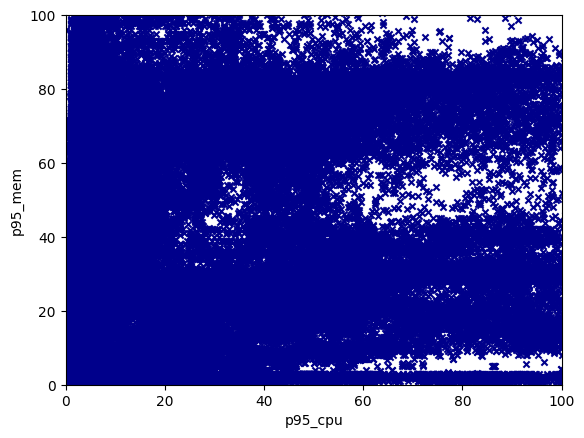

In [115]:
ax1 = df_result.plot.scatter(x='p95_cpu', y='p95_mem', c='DarkBlue', marker="x", xlim=[0, 100], ylim=[0, 100])

In [116]:
df_cost_sum = df_result[['date_key', 'ec2_cost', 'p95_cpu', 'p95_mem']]
df_cost_sum = df_cost_sum[~df_cost_sum['p95_cpu'].isna()]
df_cost_sum = df_cost_sum[~df_cost_sum['p95_mem'].isna()]

df_cost_sum.groupby('date_key').apply(lambda x: np.average(x['p95_cpu'], weights=x['ec2_cost'])).mean()

8.645950067981962

In [117]:
df_cost_sum.groupby('date_key').apply(lambda x: np.average(x['p95_mem'], weights=x['ec2_cost'])).mean()

12.634990075522161

In [118]:
df_utilization_summary = df_result[['resource_type','deployment_name', 'request_cpu', 'request_memory', 'p95_cpu' ,'p95_mem']].groupby(by=['resource_type','deployment_name', 'request_cpu', 'request_memory']).mean().reset_index()
df_utilization_summary.columns = ['resource_type','Deployment Name', 'Request CPU', 'Request Memory', 'Average CPU Utilization (%) at p95 level', 'Average Memory utilization (%) at p95 level']
df_utilization_summary

,resource_type,Deployment Name,Request CPU,Request Memory,Average CPU Utilization (%) at p95 level,Average Memory utilization (%) at p95 level
0,daemonset,aws-node,0.025,67108864.000,15.575,234.469
1,daemonset,aws-node,0.025,268435456.000,19.330,66.273
2,daemonset,dataplane-test-ds,0.030,224395264.000,4.684,19.152
3,daemonset,dataplane-test-ds,0.072,429916160.000,6.484,20.226
4,daemonset,dataplane-test-ds,0.080,492830720.000,5.014,18.110
...,...,...,...,...,...,...
4421,replicaset,vertical-pod-autoscaler-updater,0.250,671629701.000,34.474,78.175
4422,replicaset,vpa-generator,0.120,262144000.000,1.274,17.882
4423,statefulset,cloudwatch-logexport,0.220,786432000.000,8.823,72.594
4424,statefulset,cloudwatch-logexport,0.240,943718400.000,5.151,80.756


In [119]:
# We want to aggregate daily ec2_cost and saving_opportunity by sum. In order to execute this aggregation,
# 1. Select 'date_key', 'k8s_namespace', 'deployment_name', 'ec2_cost', 'saving_opportunity' columns
# 2. Group by 'date_key', 'k8s_namespace', 'deployment_name' with sum aggregation at deployment level.
# 3. Reset the index

df_dailysaving_by_name = df_result[['date_key',  'resource_type', 'deployment_name', 'ec2_cost', 'saving_opportunity']].groupby(by=['date_key',  'resource_type','deployment_name']).sum().sort_values(by=['date_key','resource_type', 'deployment_name']).reset_index()
df_dailysaving_by_name['yearly_saving'] = df_dailysaving_by_name.apply(lambda x: x['saving_opportunity'] * 365.0, axis=1)
df_dailysaving_by_name.columns = ['Date',  'Resource type', 'Name', 'Daily EC2 cost', 'Daily cost saving opportunity (USD)', 'Yearly saving opportunity estimate (USD, daily saving opportunity * 365)']
df_dailysaving_by_name

,Date,Resource type,Name,Daily EC2 cost,Daily cost saving opportunity (USD),"Yearly saving opportunity estimate (USD, daily saving opportunity * 365)"
0,20250601,daemonset,aws-node,662.524,120.958,44149.592
1,20250601,daemonset,dataplane-test-ds,2509.657,1048.341,382644.437
2,20250601,daemonset,ebs-csi-node,6477.875,3237.627,1181733.810
3,20250601,daemonset,efs-csi-node,2062.450,928.031,338731.411
4,20250601,daemonset,eks-node-monitoring-agent,0.085,0.000,0.000
...,...,...,...,...,...,...
20725,20250630,replicaset,vertical-pod-autoscaler-recommender,140.029,60.729,22166.026
20726,20250630,replicaset,vertical-pod-autoscaler-updater,143.491,60.595,22117.303
20727,20250630,replicaset,vpa-generator,0.024,0.012,4.255
20728,20250630,statefulset,cloudwatch-logexport,184.336,71.296,26022.898


In [120]:
df_daily_sum = df_dailysaving_by_name[['Date', 'Daily EC2 cost', 'Daily cost saving opportunity (USD)']].groupby(by='Date').sum().reset_index()
df_daily_sum[['Daily EC2 cost', 'Daily cost saving opportunity (USD)']].mean()

Daily EC2 cost                        26843.028
Daily cost saving opportunity (USD)   11824.917
dtype: float64

In [121]:
df_dailysaving_total_by_namespace = df_result[['date_key',  'ec2_cost', 'saving_opportunity']].groupby(by=['date_key', ]).sum().reset_index()
df_dailysaving_total_by_namespace.columns = ['Date',  'Total daily EC2 cost (USD)', 'Total daily cost saving opportunity (USD)']
df_dailysaving_total_by_namespace

,Date,Total daily EC2 cost (USD),Total daily cost saving opportunity (USD)
0,20250601,26601.308,11876.914
1,20250602,27206.514,12069.255
2,20250603,27832.323,12338.079
3,20250604,27722.474,12284.644
4,20250605,27373.310,12131.308
5,20250606,27173.471,12000.261
6,20250607,26722.570,11881.796
7,20250608,26497.270,11805.745
8,20250609,26967.624,11949.935
9,20250610,26886.466,11863.457


## Export data

In [122]:
# Export dataframe to csv files
df_utilization_summary.to_csv('./hce-costanalysis-utilization-summary-aug01_aug31_all_env.csv', index=False)
df_dailysaving_by_name.to_csv('./hce-costanalysis-cost-saving-aug01_aug31_all_env.csv', index=False)
df_dailysaving_total_by_namespace.to_csv('./hce-costanalysis-total-saving-namespace-aug01_aug31_all_env.csv', index=False)

In [123]:
withcost_hce[withcost_hce['deployment_name'] == 'ebs-csi-controller']

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory,saving_opportunity
181,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,ebs-csi-controller-5589696fc9,0.345,replicaset,ebs-csi-controller-5589696fc9,ebs-csi-controller,2.000,1.000,13.208,13.000,0.700,939524096.000,0.168
339,20250601,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,ebs-csi-controller-6cbcd77845,0.309,replicaset,ebs-csi-controller-6cbcd77845,ebs-csi-controller,1.789,1.000,15.411,13.990,0.700,939524096.000,0.150
385,20250601,aws.aws-dev2-uswest2.ast,aws-dev2-uswest2,ast,dev,sam,sam-processing1,kube-system,ebs-csi-controller-5cfb746bff,0.344,replicaset,ebs-csi-controller-5cfb746bff,ebs-csi-controller,2.000,1.000,14.000,14.000,0.700,939524096.000,0.167
437,20250601,aws.aws-dev2-uswest2.cdp1,aws-dev2-uswest2,cdp1,dev,sam,sam-processing1,kube-system,ebs-csi-controller-79d9bff4df,0.333,replicaset,ebs-csi-controller-79d9bff4df,ebs-csi-controller,1.000,1.000,10.000,10.000,0.700,939524096.000,0.162
454,20250601,aws.aws-dev2-uswest2.controltelemetry,aws-dev2-uswest2,controltelemetry,dev,sam,sam-processing1,kube-system,ebs-csi-controller-6778fb9977,0.364,replicaset,ebs-csi-controller-6778fb9977,ebs-csi-controller,1.000,1.000,12.000,12.000,0.700,939524096.000,0.177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797400,20250630,aws.test1-uswest2.security,test1-uswest2,security,test,sam,sam-mgmt-truth1,kube-system,ebs-csi-controller-d68d644d9,0.051,replicaset,ebs-csi-controller-d68d644d9,ebs-csi-controller,9.000,8.250,53.546,52.000,0.077,190382486.000,0.019
797437,20250630,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing1,kube-system,ebs-csi-controller-6f946f48b7,0.041,replicaset,ebs-csi-controller-6f946f48b7,ebs-csi-controller,8.825,7.995,63.251,62.520,0.077,203695174.000,0.016
797462,20250630,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing2,kube-system,ebs-csi-controller-5dd8698cc6,0.047,replicaset,ebs-csi-controller-5dd8698cc6,ebs-csi-controller,6.957,6.683,64.624,63.733,0.077,190382486.000,0.019
797495,20250630,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,kube-system,ebs-csi-controller-5f94f6cbc,0.051,replicaset,ebs-csi-controller-5f94f6cbc,ebs-csi-controller,11.917,11.027,64.497,63.443,0.077,190382486.000,0.017


In [124]:
only_ebscsicontroller= withcost_hce[withcost_hce['deployment_name'] == 'ebs-csi-controller'][['date_key','deployment_name', 'ec2_cost']].groupby(by=['date_key', 'deployment_name']).sum()

In [125]:
only_ebscsicontroller.to_csv('ebs-csi-controller_daily_aug01_aug31_all_env.csv')